# Association Testing

## Objective
The goal of this analysis is to investigate the relationship between Food Microbiome Exposure (FME) and gut microbiome characteristics.

Specifically, we examine whether FME is associated with:

- Alpha diversity (Shannon diversity)
- Microbiome stability
- Community composition metrics

This analysis is based on the dataset generated in the FME analysis stage.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings
pd.set_option("display.max_columns", None)

## Dataset Overview

In this section, we load and inspect the statistical dataset created in the FME analysis step.

The goal is to understand the structure of the dataset, including the number of samples, available variables, data types, and missing values before performing association testing.

In [9]:
# Load the statistical dataset created in the FME analysis step

df = pd.read_csv("fme_statistical_dataset.csv")

df.head()

,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
0,MCT.f.0002,MCTs01,2,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),67.196133,2.862675,0.049204,3.066187,15,1970.043625,109.619765,53.615264,242.919015,14.419375,74.208114,4300.616500,4.156035,0.646,1.153475,0.00000,3.969,0.9718
1,MCT.f.0003,MCTs01,3,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),81.241247,3.522832,0.049204,3.066187,15,1714.895330,89.992993,50.561373,234.225138,25.996125,67.474665,4225.813250,2.979655,0.646,1.207575,0.00000,0.000,2.9318
2,MCT.f.0004,MCTs01,4,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),126.771107,3.031188,0.049204,3.066187,15,2487.232625,94.611953,92.021551,257.539030,26.178425,83.960308,5329.882125,3.634460,0.000,1.482600,0.00000,0.000,0.9718
3,MCT.f.0005,MCTs01,5,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),31.484626,2.973836,0.049204,3.066187,15,2260.211176,110.268353,95.570253,165.608070,13.011350,64.921966,3527.501416,3.379710,0.000,1.059000,1.81440,0.000,0.9718
4,MCT.f.0006,MCTs01,6,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),61.226577,3.081097,0.049204,3.066187,15,2951.082000,161.817790,108.398516,332.637229,21.529050,119.865677,5428.573000,1.502150,0.000,0.000000,6.29596,0.000,0.4698


In [10]:
# Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (475, 27)

Columns:
['fecal_sample_id', 'participant_id', 'study_day', 'Gender', 'Age', 'BMI', 'Weight', 'Supplement', 'Medications', 'fme_score_daily', 'shannon_diversity', 'participant_shannon_cv', 'participant_shannon_mean', 'participant_n_samples', 'KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'SUGR', 'SODI', 'D_TOTAL', 'D_YOGURT', 'D_CHEESE', 'PF_MEAT', 'PF_SEAFD_HI', 'G_WHOLE']


In [11]:
# Summary statistics

df.describe()

,study_day,Age,BMI,Weight,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000
mean,8.951579,31.152211,23.174737,69.069053,73.325237,2.864593,0.062621,2.864593,14.604211,2110.562806,89.144876,91.512435,229.066013,22.337148,85.219859,3491.564185,1.921608,0.110930,0.993474,1.190717,0.325082,1.263407
std,4.939697,10.156460,3.292062,14.646855,58.307131,0.413157,0.037747,0.368406,2.429422,735.450983,37.394616,40.212887,84.487698,11.600234,43.468122,1629.773797,1.541540,0.271693,1.339567,2.307983,1.576152,1.628686
min,1.000000,19.700000,17.000000,48.500000,0.000000,1.571683,0.020213,1.944592,6.000000,722.552500,15.702908,20.467095,45.046628,3.618000,11.305484,550.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,23.900000,21.100000,59.100000,29.322198,2.610804,0.036472,2.530238,14.000000,1599.179800,62.949223,60.910505,176.968102,14.850000,53.044957,2317.423250,0.664687,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,28.500000,22.900000,66.900000,61.777509,2.964396,0.048859,3.012764,15.000000,2028.168000,85.496863,85.593670,217.000000,19.693800,81.216000,3314.340000,1.650454,0.000000,0.572400,0.000000,0.000000,0.651750
75%,13.000000,37.000000,25.900000,82.900000,104.269671,3.143011,0.079944,3.130106,16.000000,2494.098500,106.259492,116.172395,271.939905,26.711850,110.042055,4310.122600,2.754320,0.000000,1.454882,1.574200,0.000000,2.093600
max,17.000000,61.600000,31.600000,104.800000,331.223987,3.731016,0.179903,3.483381,17.000000,5085.977400,256.499039,242.761818,582.015016,67.501903,261.857405,13884.247300,9.323425,1.665000,9.047425,17.577000,20.769210,9.934594


In [13]:
print(df.isnull().sum())

fecal_sample_id               0
participant_id                0
study_day                     0
Gender                        0
Age                           0
BMI                           0
Weight                        0
Supplement                    0
Medications                 255
fme_score_daily               0
shannon_diversity             0
participant_shannon_cv        0
participant_shannon_mean      0
participant_n_samples         0
KCAL                          0
PROT                          0
TFAT                          0
CARB                          0
FIBE                          0
SUGR                          0
SODI                          0
D_TOTAL                       0
D_YOGURT                      0
D_CHEESE                      0
PF_MEAT                       0
PF_SEAFD_HI                   0
G_WHOLE                       0
dtype: int64


## Correlation Analysis

In this section, we investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity metrics.

We begin by examining the correlation between the daily FME score and Shannon diversity, which is a commonly used measure of microbiome diversity.

In [14]:
# Correlation between FME and Shannon Diversity

correlation, p_value = pearsonr(
    df["fme_score_daily"],
    df["shannon_diversity"]
)

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation: -0.0406
P-value: 0.3776


### Visualization of FME and Shannon Diversity

The following scatter plot illustrates the relationship between daily Food Microbiome Exposure (FME) scores and Shannon diversity values across all samples.

A regression line is added to help visualize the overall trend.

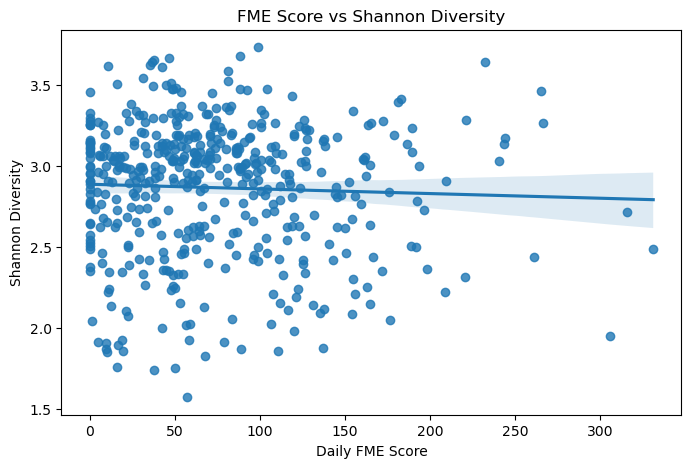

In [15]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="fme_score_daily",
    y="shannon_diversity"
)

plt.title("FME Score vs Shannon Diversity")
plt.xlabel("Daily FME Score")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The relationship between FME score and Shannon diversity appears to be weak.

Although FME values vary considerably across samples, Shannon diversity remains relatively stable.

The nearly flat regression line suggests little to no linear association between the two variables.

## Correlation Matrix

To better understand the relationships between microbiome-related variables, we compute a correlation matrix for the main numerical variables used in this analysis.

In [16]:
correlation_columns = [
    "fme_score_daily",
    "shannon_diversity",
    "participant_shannon_cv",
    "participant_shannon_mean"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean
fme_score_daily,1.000000,-0.040577,-0.077137,-0.015289
shannon_diversity,-0.040577,1.000000,-0.492850,0.891684
participant_shannon_cv,-0.077137,-0.492850,1.000000,-0.552718
participant_shannon_mean,-0.015289,0.891684,-0.552718,1.000000


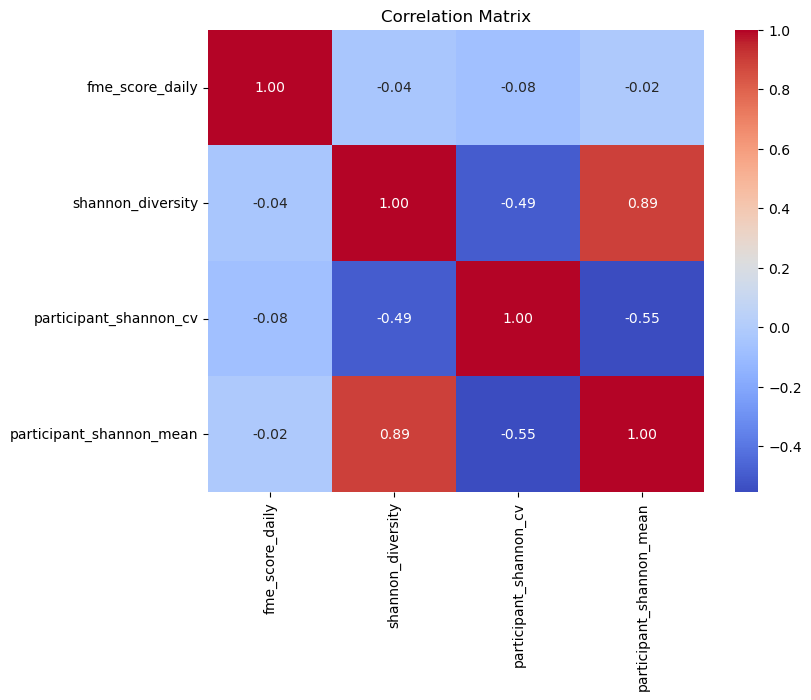

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Insight

FME score has very weak correlations with all diversity metrics.

Shannon diversity is strongly correlated with participant mean Shannon diversity.

## Comparison Between Low and High FME Groups

To further investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity, samples were divided into two groups based on the median FME score.

Shannon diversity distributions were then compared between the groups.

In [18]:
# Create FME groups based on median value

median_fme = df["fme_score_daily"].median()

df["fme_group"] = np.where(
    df["fme_score_daily"] >= median_fme,
    "High FME",
    "Low FME"
)

df["fme_group"].value_counts()

fme_group
High FME    238
Low FME     237
Name: count, dtype: int64

### Shannon Diversity by FME Group

The following boxplot compares Shannon diversity values between samples with low and high Food Microbiome Exposure.

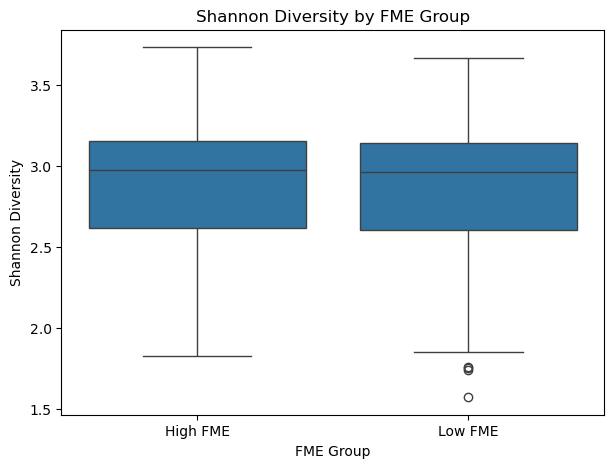

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="fme_group",
    y="shannon_diversity"
)

plt.title("Shannon Diversity by FME Group")
plt.xlabel("FME Group")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The distributions of Shannon diversity are similar in both FME groups.

No clear difference in diversity is observed between low and high FME exposure levels.

### Statistical Test

A Mann–Whitney U test was performed to evaluate whether Shannon diversity differs significantly between the two FME groups.

In [20]:
high_fme = df[df["fme_group"] == "High FME"]["shannon_diversity"]
low_fme = df[df["fme_group"] == "Low FME"]["shannon_diversity"]

stat, p_value = mannwhitneyu(high_fme, low_fme)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 28228.0
P-value: 0.9869319368980619


### Insight

No significant difference was found between the low and high FME groups (p = 0.987).

This suggests that FME levels are not associated with differences in Shannon diversity in this dataset.

## Adjusted Regression Analysis

To account for potential dietary confounders, an additional regression model was fitted including nutrient intake variables.

This allows evaluation of the association between FME and Shannon diversity while controlling for dietary factors.

In [24]:
model_adj = smf.ols(
    "shannon_diversity ~ fme_score_daily + KCAL + PROT + TFAT + CARB + FIBE",
    data=df
).fit()

print(model_adj.summary())

                            OLS Regression Results                            
Dep. Variable:      shannon_diversity   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.152
Date:                Tue, 09 Jun 2026   Prob (F-statistic):             0.0465
Time:                        20:31:00   Log-Likelihood:                -247.17
No. Observations:                 475   AIC:                             508.3
Df Residuals:                     468   BIC:                             537.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.7853      0.061     

### Insight

After adjusting for nutrient intake variables, FME score remained a non-significant predictor of Shannon diversity (p = 0.876).

This suggests that the observed lack of association is not explained by differences in dietary intake.

# Conclusions

Several statistical approaches were used to evaluate the relationship between Food Microbiome Exposure (FME) and gut microbiome diversity.

Main findings:

- The correlation between FME score and Shannon diversity was very weak.
- No significant differences were observed between low and high FME groups.
- Simple linear regression showed that FME score was not a significant predictor of Shannon diversity.
- After adjusting for dietary intake variables (KCAL, PROT, TFAT, CARB, and FIBE), FME score remained non-significant.
- Adjusting for nutrient intake did not change the overall findings.

Overall, no statistically significant association was found between FME levels and Shannon diversity in this dataset.